# Notebook \#4: Anomaly Detection
#### by Sebastian Einar Salas Røkholt

---


**Index**  
- [**1 - Introduction and Setup**](#1---introduction-and-setup)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Load the Anomaly Detection Model*](#12-load-the-forecasting-model)  
  - [*1.3 Data Preparation*](#13-data-preparation)  
- [**2 - Running Anomaly Detection**](#2---running-anomaly-detection)  
  - [*2.1 Classifying a Single Charging Session*](#21-classifying-a-single-charging-session)  
  - [*2.2 Anomaly Detection on the Test Set*](#22-calculating-anomaly-statistics) 
- [**3 - Visualising Anomalies**](#3---visualising-anomalies)  
  - [*3.1 Pre-computing Errors for Visualisation*](#31-pre-computing-errors-for-visualisation)
  - [*3.2 Interactive Anomaly Plot*](#32-interactive-anomaly-plot)
  - [*3.3 Analysis and Summary*](#33-analysis-and-summary)

---

## 1 - Introduction and Setup
This notebook investigates anomaly detection in electric vehicle (EV) charging sessions using the final forecasting model trained in the modelling notebook. The aim is to assess how well different error metrics and parameter choices separate normal from abnormal charging behaviour. Since no ground truth labels exist for the anomaly detection task, the evaluation cannot rely on quantitative measures of precision and recall. Instead, the analysis proceeds through a qualitative examination of error distributions, thresholding strategies, and visual inspection of charging curves.  

The notebook first introduces the anomaly detection setup, including model loading, data preparation, and computation of session-level errors using Macro-RMSE and RWSE. It then applies percentile-based thresholds derived from validation errors to classify test sessions. Finally, an interactive anomaly visualisation is used to explore how different metrics, thresholds, and horizon decay parameters influence classifications. This interactive approach helps to qualitatively balance precision and recall by revealing which configurations minimise false positives while still capturing genuinely abnormal behaviour.


### 1.1 Setup

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display, clear_output
from functools import lru_cache
from mt4xai.model import load_lstm_model
from mt4xai.plot import plot_raw_pred_session
from mt4xai.data import get_session_from_loader, split_data, fit_scalers_on_train, apply_scalers, build_loader
from mt4xai.inference import compute_session_MRMSE, compute_session_RWSE, fit_rwse_robust_scalers, \
                      classify_by_threshold, percentile_threshold, percentile_of_threshold, make_bundle_from_session_df

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
CLEANED_DATA_PATH = os.path.join(PROJECT_ROOT, "Data", "etron55-charging-sessions.parquet")

FINAL_MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models/final")
FINAL_MODEL_PATH = os.path.join(FINAL_MODEL_FOLDER_PATH, "final_model.pth")

PCT_THRESHOLD = 95.0  # Percentile for anomaly detection threshold
T_MIN_EVAL = 1  # Only evaluate and plot predictions for t >= T_MIN_EVAL + 1

print("[env] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[env] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Jupyter Notebook settings
%matplotlib inline
%load_ext autoreload
%autoreload 2

[env] CUDA available: True
[env] Device: NVIDIA GeForce RTX 4070 Laptop GPU


### 1.2 Load the Forecasting Model

In [2]:
# Loads a trained LSTM model from disk
model, checkpoint = load_lstm_model(FINAL_MODEL_PATH, device=DEVICE)

input_features = checkpoint["input_features"]
target_features = checkpoint["target_features"]
cfg = checkpoint["config"]
HORIZON = int(cfg["horizon"])
POWER_WEIGHT = float(cfg.get("power_weight", 0.5))

# Indices of targets within the *input* feature vector (used for reconstruction)
idx_power_inp = input_features.index("power")
idx_soc_inp = input_features.index("soc")


/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/src/mt4xai/model.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

### 1.3 Data Preparation
In this section, we will load, transform, and split the data in exactly the same way as we did previously in order to extract the test set for running anomaly detection tests.

In [3]:
# Loads the cleaned data (already wrangled)
df_cleaned = pd.read_parquet(CLEANED_DATA_PATH)  # TODO: Replace with raw data and apply wrangling pipeline
# Removes features that aren't used to classify charging sessions
df = df_cleaned.drop(labels=['energy', 'charger_category', 'timestamp', 
                             'nearest_weather_station', 'timestamp_d', 'lat', 'lon', 'timestamp_H'], axis=1)

# Split exactly like the modelling notebook
train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1)

# Fit scalers on train and apply to val/test (same as modelling)
cols_to_scale = list(set(input_features) | set(target_features))
scalers = fit_scalers_on_train(train_df, cols_to_scale)
power_scaler, soc_scaler = scalers["power"], scalers["soc"]  # Extract for later use
train_s = apply_scalers(train_df, scalers)
val_s = apply_scalers(val_df, scalers)
test_s = apply_scalers(test_df, scalers)

# Builds the DataLoaders to iterate over charging sessions
val_loader = build_loader(val_s,  input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)
test_loader = build_loader(test_s, input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)

## 2 - Running Anomaly Detection

### 2.1 Classifying a Single Charging Session
In this section, we compute the Macro-RMSE and RWSE of a single charging session and classify it as normal or abnormal. 
The classification threshold for each error metric is arbitrarily chosen. 

In [4]:
# Specifying session by batch + sample index within test set
sid, X, Y, L = get_session_from_loader(test_loader, session_idx=0, batch_idx=0)
sid_list = [sid]

# Computes Macro-RMSE
session_mrse = compute_session_MRMSE(
    model=model,
    loader=[(sid_list, X, Y, L)],
    device=DEVICE,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    t_min_eval=T_MIN_EVAL,
    horizon_weights_decay=0.4,
).error.iloc[0]

# Computes RWSE by fitting robust scalers on validation set
m_rwse, mad_rwse = fit_rwse_robust_scalers(
    model=model,
    df_scaled=val_s,
    device=DEVICE,
    input_features=input_features,
    target_features=target_features,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    horizon=HORIZON,
    t_min_eval=T_MIN_EVAL,
)

session_rwse = compute_session_RWSE(
    model, session_ids=[sid], df_scaled=test_s, device=DEVICE, input_features=input_features, 
    target_features=target_features, power_scaler=power_scaler, soc_scaler=soc_scaler, 
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, m=m_rwse, mad=mad_rwse,
    horizon=HORIZON, horizon_weights_decay=0.4, 
    t_min_eval=T_MIN_EVAL).error.iloc[0]

# Setting arbitrarily chosen error thresholds for each metric
mrmse_thr = 10.0
rwse_thr = 3.0

mrmse_label = "ABNORMAL" if session_mrse > mrmse_thr else "NORMAL"
rwse_label = "ABNORMAL" if session_rwse > rwse_thr else "NORMAL"

print(f"Anomaly detection on session {sid}:")
print(f"Macro-RMSE = {session_mrse:.3f}, Macro-RMSE AD threshold = {mrmse_thr:.3f} ---> Classification = {mrmse_label}")
print(f"RWSE = {session_rwse:.3f}, RWSE AD threshold = {rwse_thr:.3f} ---> Classification = {rwse_label}")

Anomaly detection on session 5128923:
Macro-RMSE = 1.027, Macro-RMSE AD threshold = 10.000 ---> Classification = NORMAL
RWSE = 7.360, RWSE AD threshold = 3.000 ---> Classification = ABNORMAL


In [5]:
# Classify by explicit session_id
sid, X2, Y2, L2 = get_session_from_loader(test_loader, session_id=1691162)
sid_list = [sid]

# Computes Macro-RMSE
session_mrse = compute_session_MRMSE(
    model=model,
    loader=[(sid_list, X2, Y2, L2)],
    device=DEVICE,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    t_min_eval=T_MIN_EVAL,
    horizon_weights_decay=0.4,
).error.iloc[0]

# Computes RWSE by fitting robust scalers on validation set
m_rwse, mad_rwse = fit_rwse_robust_scalers(
    model=model,
    df_scaled=val_s,
    device=DEVICE,
    input_features=input_features,
    target_features=target_features,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    horizon=HORIZON,
    t_min_eval=T_MIN_EVAL,
)

session_rwse = compute_session_RWSE(
    model, session_ids=[sid], df_scaled=test_s, device=DEVICE, input_features=input_features, 
    target_features=target_features, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, m=m_rwse, mad=mad_rwse,
    horizon=HORIZON, horizon_weights_decay=0.4, 
    t_min_eval=T_MIN_EVAL).error.iloc[0]

# Setting arbitrarily chosen error thresholds for each metric
mrmse_thr = 10.0
rwse_thr = 3.0

mrmse_label = "ABNORMAL" if session_mrse > mrmse_thr else "NORMAL"
rwse_label = "ABNORMAL" if session_rwse > rwse_thr else "NORMAL"

print(f"Anomaly detection on session {sid}:")
print(f"Macro-RMSE = {session_mrse:.3f}, Macro-RMSE AD threshold = {mrmse_thr:.3f} ---> Classification = {mrmse_label}")
print(f"RWSE = {session_rwse:.3f}, RWSE AD threshold = {rwse_thr:.3f} ---> Classification = {rwse_label}")

Anomaly detection on session 1691162:
Macro-RMSE = 0.340, Macro-RMSE AD threshold = 10.000 ---> Classification = NORMAL
RWSE = 21.172, RWSE AD threshold = 3.000 ---> Classification = ABNORMAL


### 2.2 Anomaly Detection on the Test Set
In order to determine an appropriate classification threshold for each metric, we first calculate the distribution of errors of the validation set and all errors of the test set. To classify the sessions in the test set, we set the classification threshold to the nth percentile of errors for the validation set. In this section, we will classify all sessions in the test set based on an arbitrarily selected percentile threshold (95th percentile).

#### 2.2.1 Computing Macro-RMSE and RWSE

**Weighted Macro Root Mean Squared Error (Macro-RMSE)**</br>

Given predictions $(\hat{y}_{t,h,c})$ and true values $(y_{t,h,c})$, where $(t)$ indexes time, $(h \in \{1,\dots,H\})$ is the prediction horizon, and $(c \in \{1,2\})$ denotes the target variables (power, SOC), the per-horizon-channel RMSE is

$$
\text{RMSE}_{h,c} = \sqrt{ \frac{1}{T_{h,c}} \sum_{t=1}^{T_{h,c}} \big( y_{t,h,c} - \hat{y}_{t,h,c} \big)^2 }.
$$

With horizon weights $w_h$ that satisfy $\sum_{h=1}^{H} w_h = 1$ (e.g., $w_h \propto e^{-\lambda (h-1)}$), the session-level **Macro-RMSE** is

$$
\text{MacroRMSE} \;=\; \sum_{h=1}^{H} w_h \,\Big[\, w \cdot \text{RMSE}_{h,\text{power}} \;+\; (1-w) \cdot \text{RMSE}_{h,\text{soc}} \,\Big],
$$

where $w$ is the power weight and $\lambda \ge 0$ is the horizon-decay hyperparameter.


**Robust Weighted Standardized Error (RWSE)** </br>
To calculate the RWSE, we adjust residuals by their median and median absolute deviation (MAD) computed on the validation set, then apply the weights across the prediction horizons and targets.  

The residuals are defined as:

$$
r_{t,h,c} = y_{t,h,c} - \hat{y}_{t,h,c}
$$

For each horizon $h$ and channel $c$, we compute the median $(m_{h,c})$ and median absolute deviation $(\text{MAD}_{h,c})$ from validation residuals. The standardized residuals are then:

$$
z_{t,h,c} = \frac{|\,r_{t,h,c} - m_{h,c}\,|}{\text{MAD}_{h,c}}
$$

with values clipped at a cap (e.g. $z_{t,h,c} \leq 5.0$).  

To combine errors across horizons and targets, we apply the weights:
- Horizon weights $w_h$ (exponential decay, normalized to sum to 1)  
- Target weights $w_c$ (uniform over channels, sum to 1)  

Therefore, the RWSE for a session is:

$$
\text{RWSE} = \frac{1}{T'} \sum_{t=1}^{T'} \sum_{h=1}^{H} \sum_{c=1}^{C} w_h \, w_c \, z_{t,h,c}
$$

where:
- $T'$ = number of evaluated time steps (after $t_{\min}^{eval}$)  
- $H$ = number of horizons  
- $C$ = number of target variables (power, SOC)  



In [6]:
# horizon weight (λ) defaults
DEFAULT_DECAY_MRMSE = 0.40  # Set to 0.0 for uniform averaging across horizons
DEFAULT_DECAY_RWSE  = 0.40

# Macro-RMSE
df_val_err_mrmse = compute_session_MRMSE(
    model=model,
    loader=val_loader,
    device=DEVICE,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    t_min_eval=T_MIN_EVAL,
    horizon_weights_decay=DEFAULT_DECAY_MRMSE,
)
df_test_err_mrmse = compute_session_MRMSE(
    model=model,
    loader=test_loader,
    device=DEVICE,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    t_min_eval=T_MIN_EVAL,
    horizon_weights_decay=DEFAULT_DECAY_MRMSE,
)

# RWSE
m_rwse, mad_rwse = fit_rwse_robust_scalers(
    model=model,
    df_scaled=val_s,
    device=DEVICE,
    input_features=input_features,
    target_features=target_features,
    power_scaler=power_scaler,
    idx_power_inp=idx_power_inp,
    horizon=HORIZON,
    t_min_eval=T_MIN_EVAL,
)
df_val_err_rwse = compute_session_RWSE(
    model, val_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, horizon_weights_decay=DEFAULT_DECAY_RWSE,
    power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    m=m_rwse, mad=mad_rwse, cap=5.0, t_min_eval=T_MIN_EVAL
)
df_test_err_rwse = compute_session_RWSE(
    model, test_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, horizon_weights_decay=DEFAULT_DECAY_RWSE,
    power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    m=m_rwse, mad=mad_rwse, cap=5.0, t_min_eval=T_MIN_EVAL
)

#### 2.2.2 Classifying Charging Sessions
We classify each charging session by labelling it as "abnormal" when the model's prediction error for the session is above the anomaly detection threshold. Sessions below the threshold are labelled as "normal". 

In [7]:
# Classifies sessions in test set
pct_thresh = PCT_THRESHOLD  # Percentile for anomaly detection threshold, e.g. 95.0
 
# with Macro-RMSE at error threshold computed on validation set
mrmse_thr = percentile_threshold(np.sort(df_val_err_mrmse["error"].to_numpy()), pct_thr=pct_thresh)
mrmse_test_cls_df = classify_by_threshold(df_test_err_mrmse, mrmse_thr)

# with RWSE at error threshold computed on validation set
rwse_thr = percentile_threshold(np.sort(df_val_err_rwse["error"].to_numpy()), pct_thr=pct_thresh)
rwse_test_cls_df = classify_by_threshold(df_test_err_rwse, rwse_thr)

print(f"\nClassification counts:\n Macro-RMSE: {mrmse_test_cls_df["label"].value_counts().to_string()}\n \
      RWSE: {rwse_test_cls_df["label"].value_counts().to_string()}")


Classification counts:
 Macro-RMSE: label
normal      11603
abnormal      580
       RWSE: label
normal      11631
abnormal      552


#### 2.2.3 Calculating Anomaly Statistics

In [8]:
# Session lengths
min_session_len = int(mrmse_test_cls_df["length"].min())
max_session_len = int(mrmse_test_cls_df["length"].max())

# Macro-RMSE metric stats
all_mrmse = mrmse_test_cls_df["error"].to_numpy()
all_mrsmse_sorted = np.sort(all_mrmse)
mrmse_min_err, mrmse_max_err = float(all_mrsmse_sorted[0]), float(all_mrsmse_sorted[-1])


# Global y-limit for power (kept for plotting UI)
y_lim_power = (
    0.0,
    float(power_scaler.inverse_transform(test_s[["power"]].to_numpy(np.float32)).max())
)

print(f"Macro_RMSE threshold @ {pct_thresh:.1f}th pct = {mrmse_thr:.4f}")
print(f"RWSE threshold @ {pct_thresh:.1f}th pct = {rwse_thr:.4f}")
print(f"\nLowest-RMSE (most normal) sessions:\n{mrmse_test_cls_df.sort_values("error").head(5)}")
print(f"\nHighest-RMSE (most abnormal) sessions:\n{mrmse_test_cls_df.sort_values("error", ascending=False).head(3)}")
print(f"\nError ranges: Macro-RMSE ∈ [{mrmse_min_err:.3f}, {mrmse_max_err:.3f}], ...")
print(f"Session length range: [{min_session_len}, {max_session_len}] time steps")
print(f"Max power output: {y_lim_power[1]:.1f} kW")


Macro_RMSE threshold @ 95.0th pct = 12.9682
RWSE threshold @ 95.0th pct = 53.0422

Lowest-RMSE (most normal) sessions:
   charging_id     error  length   label
0      7080318  0.067949      12  normal
1      8065017  0.099324      14  normal
2      6791928  0.099591      10  normal
3      4723841  0.109297      10  normal
4     11397514  0.113187      22  normal

Highest-RMSE (most abnormal) sessions:
       charging_id      error  length     label
12182     11732342  83.235748      15  abnormal
12181      1836322  60.604023      15  abnormal
12180      5649864  51.750130      45  abnormal

Error ranges: Macro-RMSE ∈ [0.068, 83.236], ...
Session length range: [8, 60] time steps
Max power output: 199.6 kW


To better understand the baseline error levels and to set anomaly thresholds,
we visualize the distribution of Macro-RMSE and RWSE on the validation set. The histogram and Kernel Density Estimation (KDE) for each distribution is shown on the same plot, along with the selected thresholds. 

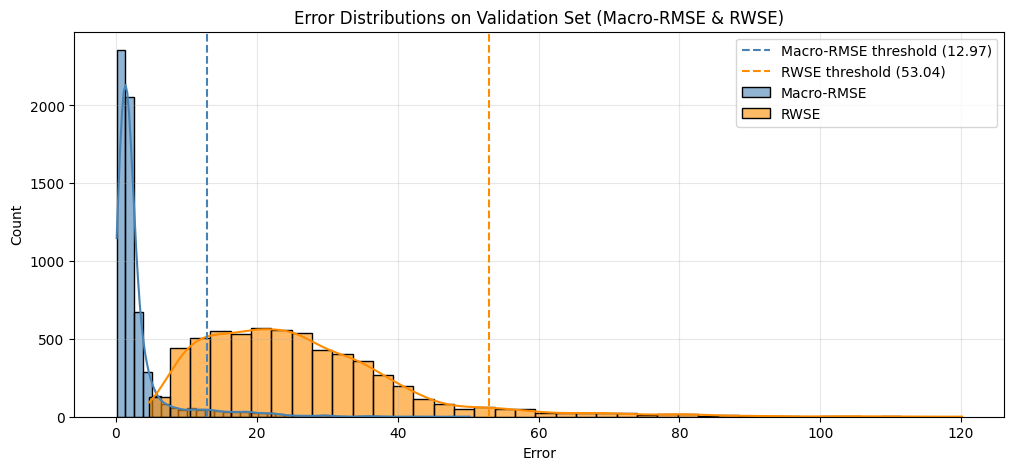

In [9]:
plt.figure(figsize=(12,5))

# Macro-RMSE distribution
sns.histplot(df_val_err_mrmse["error"], kde=True, bins=40, color="steelblue", alpha=0.6, label="Macro-RMSE")

# RWSE distribution
sns.histplot(df_val_err_rwse["error"], kde=True, bins=40, color="darkorange", alpha=0.6, label="RWSE")

plt.axvline(mrmse_thr, color="steelblue", linestyle="--", linewidth=1.5, label=f"Macro-RMSE threshold ({mrmse_thr:.2f})")
plt.axvline(rwse_thr, color="darkorange", linestyle="--", linewidth=1.5, label=f"RWSE threshold ({rwse_thr:.2f})")

plt.xlabel("Error")
plt.ylabel("Count")
plt.title("Error Distributions on Validation Set (Macro-RMSE & RWSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3 - Visualising Anomalies
In this section, we will use an interactive anomaly plot to explore how charging sessions are classified as normal or abnormal under different metrics and parameters. As we don't have true labels the anomaly detection task ("normal" vs "abnormal" for each charging session), we need to conduct a quantitative analysis in order to determine which metric and parameters to use going forward. 


### 3.1 Pre-computing Errors for Visualisation

In [10]:
# Precomputes the error tables for different λ values, s.t. they can be selected in the UI without recomputation
DECAY_GRID = [0.0, 0.2, 0.4, 0.6, 2.0]  # λ selection range
ERR_PRECOMP = {"macro_rmse": {}, "rwse": {}}

def precompute_tables_for_horizon_decay(horizon_decay: float):
    # Macro-RMSE
    val_m = compute_session_MRMSE(
        model=model,
        loader=val_loader,
        device=DEVICE,
        power_scaler=power_scaler,
        idx_power_inp=idx_power_inp,
        t_min_eval=T_MIN_EVAL,
        horizon_weights_decay=horizon_decay,
    )
    test_m = compute_session_MRMSE(
        model=model,
        loader=test_loader,
        device=DEVICE,
        power_scaler=power_scaler,
        idx_power_inp=idx_power_inp,
        t_min_eval=T_MIN_EVAL,
        horizon_weights_decay=horizon_decay,
    )
    ERR_PRECOMP["macro_rmse"][horizon_decay] = {"val": val_m, "test": test_m, "label": "Macro-RMSE"}

    # RWSE 
    val_r = compute_session_RWSE(
        model, val_s, device=DEVICE, input_features=input_features, target_features=target_features,
        horizon=HORIZON, horizon_weights_decay=horizon_decay,
        power_scaler=power_scaler, soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
        m=m_rwse, mad=mad_rwse, cap=5.0, t_min_eval=T_MIN_EVAL
    )
    test_r = compute_session_RWSE(
        model, test_s, device=DEVICE, input_features=input_features, target_features=target_features,
        horizon=HORIZON, horizon_weights_decay=horizon_decay,
        power_scaler=power_scaler, soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
        m=m_rwse, mad=mad_rwse, cap=5.0, t_min_eval=T_MIN_EVAL
    )
    ERR_PRECOMP["rwse"][horizon_decay] = {"val": val_r, "test": test_r, "label": "RWSE"}

for lam in DECAY_GRID:
    print(f"Computing errors for λ = {lam:.1f}")
    precompute_tables_for_horizon_decay(lam)

Computing errors for λ = 0.0


Computing errors for λ = 0.2
Computing errors for λ = 0.4
Computing errors for λ = 0.6
Computing errors for λ = 2.0


### 3.2 Interactive Anomaly Plot

The interactive plot allows us to adjust different parameters:
- **Classification switch**: toggles the classification: "Normal" vs "abnormal".
- **Session index**: Used to navigate between different sessions. The sessions are sorted by error. 
- **Session selector**: Jump to a specific charging session by entering its session ID. 
- **Session length**: Constrain available sessions by session length.
- **Metric selection**: switches between Macro-RMSE and RWSE to calculate prediction error. 
- **Horizon decay (λ)**: Change how the error is computed by adjusting the horizon weight decay parameter $\lambda$. Higher $\lambda$ => prediction error for longer horizons are less important, while higher λ emphasizes shorter-term prediction accuracy. A $\lambda$ of 0.0 ensures uniform horizon weights. 
- **Error**: Filter the error range s.t. error $\in [lower\_limit, higher\_limit]$.
- **Classification threshold**: Adjusts the decision boundary that separates normal from abnormal sessions. 
- **Reset button**: The plot has a button that resets the current filters and refreshes the plot(s).

By experimenting with these controls, we expect to see that RMSE-based abnormalities tend to be *spiky* or *erratic* sessions, as single-step deviations (sudden drops or jumps) create large squared errors. On the other hand, RWSE-based abnormalities are less sensitive to isolated spikes, because residuals are normalized by robust statistics. Therefore, we expect that RWSE-based anomalies contain sessions with unusual overall shapes or deviations from typical charging trends. These tend to be smoother but systematically different curves, rather than noisy ones.  

In [ ]:
# --------------------------------- UI DEFAULTS ------------------------------------ #
DEFAULT_METRIC = "macro_rmse"
DECAY_DEFAULTS = {"macro_rmse": DEFAULT_DECAY_MRMSE, "rwse": DEFAULT_DECAY_RWSE}
_current_decay = float(DECAY_DEFAULTS[DEFAULT_METRIC])

# --------------------------------- Cache bundles (faster lookup) --------------------------- #
@lru_cache(maxsize=2048)
def _cached_bundle(sid: int):
    return make_bundle_from_session_df(
        model=model, df_scaled=test_s, sid=sid, device=DEVICE,
        input_features=input_features, target_features=target_features, horizon=HORIZON,
        power_scaler=power_scaler, soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp
    )

# --------------------------------- RANGES AND TABLES -------------------------------- #
def calc_ranges():
    errs = df_test_errs["error"].dropna().to_numpy()
    if errs.size == 0:
        return 0.0, 1.0, 0, 1, np.array([0.0, 1.0]), 0.5
    all_sorted = np.sort(errs)
    err_min, err_max = float(all_sorted[0]), float(all_sorted[-1])

    lengths = df_test_errs["length"].dropna().to_numpy()
    len_min, len_max = int(lengths.min()), int(lengths.max())

    thr = percentile_threshold(np.sort(df_val_err["error"].dropna().to_numpy()), pct_thr=PCT_THRESHOLD)
    return err_min, err_max, len_min, len_max, all_sorted, thr

def choose_metric_tables(metric_key: str, lam: float):
    if metric_key not in ERR_PRECOMP or lam not in ERR_PRECOMP[metric_key]:
        raise ValueError(f"No tables for metric={metric_key}, λ={lam}")
    d = ERR_PRECOMP[metric_key][lam]
    return d["val"].copy(), d["test"].copy(), d["label"]

def set_tables(metric_key: str, lam: float):
    global df_val_err, df_test_errs, METRIC_LABEL
    df_val_err, df_test_errs, METRIC_LABEL = choose_metric_tables(metric_key, lam)


# --------------------------------- UI WIDGETS (POWER-ONLY) --------------------------- #
w_metric = widgets.ToggleButtons(
    options=[("Macro-RMSE", "macro_rmse"), ("RWSE", "rwse")],
    value=DEFAULT_METRIC, description="Metric", layout=Layout(width="100%")
)

w_cls = widgets.ToggleButtons(
    options=[("Normal", "normal"), ("Abnormal", "abnormal")],
    value="abnormal", description="Class", layout=Layout(width="100%")
)

w_decay = widgets.SelectionSlider(
    options=[(f"λ={v:.1f}", v) for v in DECAY_GRID],
    value=min(DECAY_GRID, key=lambda v: abs(v - _current_decay)),
    description="Horizon weight decay", continuous_update=False,
    layout=Layout(width="100%"), style={"description_width": "initial"}
)

w_idx = widgets.IntSlider(value=0, min=0, max=0, step=1,
                          description="Index", continuous_update=False,
                          layout=Layout(width="100%"))

w_reset = widgets.Button(description="Reset filters", icon="refresh",
                         layout=Layout(width="100%"))

# Load initial tables
df_val_err, df_test_errs, METRIC_LABEL = choose_metric_tables(DEFAULT_METRIC, w_decay.value)
set_tables(DEFAULT_METRIC, w_decay.value)
m_err_min, m_err_max, min_session_len, max_session_len, _sorted, m_thr = calc_ranges()

# Dynamic range widgets
w_len = widgets.IntRangeSlider(
    value=[min_session_len, max_session_len], min=min_session_len, max=max_session_len,
    step=1, description="Length ∈", continuous_update=False, layout=Layout(width="100%")
)

w_err = widgets.FloatRangeSlider(
    value=[m_err_min, m_err_max], min=m_err_min, max=m_err_max,
    step=(m_err_max - m_err_min) / 500 if m_err_max > m_err_min else 1e-3,
    description="Error ∈", readout_format=".2f", continuous_update=False,
    layout=Layout(width="80%")
)

w_thr = widgets.FloatSlider(
    value=m_thr, min=m_err_min, max=m_err_max,
    step=(m_err_max - m_err_min) / 300 if m_err_max > m_err_min else 1e-3,
    description="Classification Threshold", readout_format=".3f",
    continuous_update=False, layout=Layout(width="70%"),
    style={"description_width": "initial"}
)

w_thr_pct = widgets.HTML(
    value=f"<b>{percentile_of_threshold(_sorted, w_thr.value):.1f}th</b> percentile"
)

sid_options = list(map(str, sorted(df_test_errs["charging_id"].unique())))
w_sid = widgets.Combobox(
    placeholder="Jump to session id…", options=sid_options, value="",
    description="Session", ensure_option=False, layout=Layout(width="100%")
)

out = widgets.Output()


# --------------------------------- FILTERING + UPDATE FUNCTIONS --------------------------- #
def retune_ranges():
    global m_err_min, m_err_max, min_session_len, max_session_len, _sorted, m_thr
    m_err_min, m_err_max, min_session_len, max_session_len, _sorted, m_thr = calc_ranges()
    w_len.min = min_session_len;  w_len.max = max_session_len; w_len.value = [min_session_len, max_session_len]
    w_err.min = m_err_min; w_err.max = m_err_max
    w_err.step = (m_err_max - m_err_min) / 500 if m_err_max > m_err_min else 1e-3
    w_err.value = [m_err_min, m_err_max]
    w_thr.min = m_err_min; w_thr.max = m_err_max
    w_thr.step = (m_err_max - m_err_min) / 300 if m_err_max > m_err_min else 1e-3
    w_thr.value = m_thr
    w_thr_pct.value = f"<b>{percentile_of_threshold(_sorted, w_thr.value):.1f}th</b> percentile"

def filtered_df(cls_label: str, thr: float, len_lo: int, len_hi: int, err_lo: float, err_hi: float):
    df = df_test_errs.dropna(subset=["error"]).copy()
    df = df[(df["length"] >= len_lo) & (df["length"] <= len_hi) &
            (df["error"]  >= err_lo) & (df["error"]  <= err_hi)].copy()
    df = classify_by_threshold(df, thr)
    df = df[df["label"] == cls_label]
    return df.sort_values("error", ascending=(cls_label == "normal")).reset_index(drop=True)

def update_index_range(*_):
    df = filtered_df(w_cls.value, w_thr.value, w_len.value[0], w_len.value[1], w_err.value[0], w_err.value[1])
    w_idx.max = max(0, len(df) - 1)
    w_thr_pct.value = f"<b>{percentile_of_threshold(_sorted, w_thr.value):.1f}th</b> percentile"
    render_plots()

def jump_to_sid(*_):
    sid_str = (w_sid.value or "").strip()
    if not sid_str.isdigit():
        return
    sid = int(sid_str)
    df = filtered_df(w_cls.value, w_thr.value, w_len.value[0], w_len.value[1], w_err.value[0], w_err.value[1])
    pos = np.where(df["charging_id"].to_numpy() == sid)[0]
    if len(pos):
        w_idx.value = int(pos[0])

def reset_filters(_btn=None):
    retune_ranges()
    w_idx.value = 0
    w_sid.value = ""

def render_plots(*_):
    df = filtered_df(
        w_cls.value,
        w_thr.value,
        w_len.value[0], w_len.value[1],
        w_err.value[0], w_err.value[1]
    )

    with out:
        clear_output(wait=True)

        if len(df) == 0:
            print(f"[{METRIC_LABEL}] No sessions match the current filter.")
            return

        row = df.iloc[min(w_idx.value, len(df) - 1)]
        sid   = int(row["charging_id"])
        err   = float(row["error"])
        lbl   = row["label"]

        bundle = _cached_bundle(sid)
        title_suffix = f"{lbl.upper()} — Error={err:.3f} (Threshold={w_thr.value:.3f})"

        # Call the plotting function exactly as defined in mt4xai.plot
        plot_raw_pred_session(
            bundle,
            power_scaler,
            soc_scaler,
            idx_power_inp,
            idx_soc_inp,
            t_min_eval=T_MIN_EVAL,
            figsize=(10, 5),
            dpi=300, 
            y_lim_power=y_lim_power, 
            title_suffix=title_suffix
        )

        print(f"[{METRIC_LABEL}] {len(df)} sessions match filters — "
              f"Index {w_idx.value+1}/{len(df)}")


# --------------------------------- OBSERVERS --------------------------- #
def on_metric_change(change):
    if change["name"] != "value": return
    metric = change["new"]
    default_lam = float(DECAY_DEFAULTS[metric])
    w_decay.value = min(DECAY_GRID, key=lambda v: abs(v - default_lam))
    set_tables(metric, w_decay.value)
    retune_ranges()
    reset_filters()

def on_decay_change(change):
    if change["name"] != "value": return
    set_tables(w_metric.value, float(change["new"]))
    retune_ranges()
    reset_filters()

w_metric.observe(on_metric_change, names="value")
w_decay.observe(on_decay_change,   names="value")

for w in (w_cls, w_thr, w_len, w_err):
    w.observe(update_index_range, names="value")

w_idx.observe(render_plots, names="value")
w_sid.observe(jump_to_sid, names="value")
w_reset.on_click(reset_filters)

# --------------------------------- LAYOUT --------------------------- #
col1 = widgets.VBox([w_cls], layout=Layout(width="18%"))
col2 = widgets.VBox([w_idx, w_sid, w_len], layout=Layout(width="25%"))
col3 = widgets.VBox([w_metric, w_decay, w_err, widgets.HBox([w_thr, w_thr_pct])],
                    layout=Layout(width="42%"))
col4 = widgets.VBox([w_reset], layout=Layout(width="12%"))

top_row = widgets.HBox([col1, col2, col3, col4],
                       layout=Layout(width="100%", justify_content="space-between"))

ui = widgets.VBox([top_row, out], layout=Layout(width="100%"))

# --------------------------------- INITIAL RENDER --------------------------- #
retune_ranges()
reset_filters()
update_index_range()

display(ui)


### 3.3 Analysis and Summary

The exploration of classifications using the interactive anomaly visualisation highlights the trade-off between precision and recall in the context of electric vehicle charging curve anomaly detection. Investigations into "abnormal behaviour" can be expensive for EV owners and for the charging station operator. Precision is therefore of primary importance, meaning that the anomaly detector should avoid producing false positives. However, the absence of ground truth labels for the anomaly detection stage of this project prevents us from conducting a quantitative evaluation of precision and recall. The qualitative analysis of error distributions and session shapes has therefore proven essential.

By investigating the detected anomalies under different classification parameters, we discovered that a Weighted Macro-RMSE metric with a moderate horizon decay yields few false positives when used with a threshold set at the 95th percentile (of the validation set). Lowering the threshold increases recall, but reduces precision substantially by introducing more spurious detections, while raising it further increases precision at the cost of missing some genuine anomalies. We have therefore decided to keep the percentile threshold high (at the 95th percentile or higher) in the future. The qualitative differences between metrics also became evident: RMSE-based anomalies typically correspond to spiky or unstable sessions, which are highly penalised by squared errors, whereas RWSE is less sensitive to isolated spikes due to normalization by median and MAD. RWSE instead highlights sessions with systematic but smoother deviations, which in some cases reduces its ability to capture abnormal high-variance sessions. Using RWSE might make it more difficult for humans to interpret the results with a simplified classification heuristic.

Based on these findings, the RMSE-based metric with a modest horizon decay of 0.2 and a 95th percentile threshold will be used going forward, as this configuration provides a balanced trade-off that prioritises precision while retaining sensitivity to clearly abnormal charging behaviour.

In [13]:
from mt4xai.inference import classify_session

# sid = int(df_test_err_mrmse.sort_values("error", ascending=False)["charging_id"].iloc[0])  # top abnormal
sid = 7753775
mrmse_thr = percentile_threshold(np.sort(df_val_err_mrmse["error"].to_numpy()), pct_thr=95)

# classify the selected session in the test set
label, err = classify_session(
    model=model,
    sid=sid,
    df_scaled=test_s,
    device=DEVICE,
    input_features=input_features,
    target_features=target_features,
    horizon=HORIZON,
    power_scaler=power_scaler,
    soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp,
    idx_soc_inp=idx_soc_inp,
    power_weight=0.5,
    decay=0.2,
    t_min_eval=T_MIN_EVAL,
    threshold=mrmse_thr
)

print(f"[Macro-RMSE] session {sid} → error={err:.4f}, threshold={mrmse_thr:.4f}, label={'ABNORMAL' if label else 'NORMAL'}")

[Macro-RMSE] session 7753775 → error=22.8044, threshold=12.9682, label=ABNORMAL
